### Here GPT will actually learn Shakespeare

In [2]:
import torch
import torch.nn.functional as F

import matplotlib.pyplot as plt

MAX_ITERS = 5000

EVAL_INTERVAL = 250

EVAL_ITERS = 100

LEARNING_RATE = 3e-4

WEIGHT_DECAY = 0.01

device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [3]:
# Importing MiniGPT from notebook 6
import importlib

# 1. Use importlib to dynamically load the notebook 6 module
notebook06_module = importlib.import_module("ipynb.fs.full.06_MiniGPT-Model")

# 2. Extract the class from the loaded module
MiniGPT = notebook06_module.MiniGPT


torch.Size([2, 10, 256])
788,992
torch.Size([2, 128, 256])
7,332,232
torch.Size([512, 5000])
tensor(8.7198, grad_fn=<NllLossBackward0>)


In [4]:
# Hyperparameters
VOCAB_SIZE = 5000

EMBED_DIM = 256

NUM_HEADS = 8

NUM_LAYERS = 6

BLOCK_SIZE = 128

DROPOUT = 0.1

model = MiniGPT(

    vocab_size=VOCAB_SIZE,

    embed_dim=EMBED_DIM,

    block_size=BLOCK_SIZE,

    num_heads=NUM_HEADS,

    num_layers=NUM_LAYERS

)
model = model.to(device)

In [5]:
# Parameter count
total_params = sum(

    p.numel()

    for p in model.parameters()

)

print(
    f"{total_params:,}"
)

7,332,232


In [6]:
#Optimizer
# GPT uses AdamW
optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=LEARNING_RATE,

    weight_decay=WEIGHT_DECAY

)

In [7]:
# Validation Function
@torch.no_grad()
def estimate_loss():
    # Set evaluation mode
    model.eval()
    # Create result dictionary
    out = {}
    # Looping over train and validation
    for split in [
        "train",
        "val"
    ]:
        # Store losses
        losses = torch.zeros(
            EVAL_ITERS
        )
        # Evaluation loop
        for k in range(
            EVAL_ITERS
        ):
            # Get batch
            xb,yb = get_batch(
                split
            )
             # Move to GPU
            xb = xb.to(device)

            yb = yb.to(device)
           #Forward pass.
            _, loss = model(
                xb,
                yb
            )

            losses[k] = (
                loss.item()
            )
        # Mean loss
        out[split] = (
            losses.mean()
        )

    model.train()

    return out

In [8]:
# Trainging history - store losses
train_losses = []

val_losses = []

In [9]:
# Importing GetBatch from notebook 7
import importlib

# 1. Use importlib to dynamically load the notebook 7 module
notebook07_module = importlib.import_module("ipynb.fs.full.07_GPT-DatasetPipeline")

# 2. Extract the class from the loaded module
get_batch = notebook07_module.get_batch


Tokenizer Loaded
Dataset Length: 1115394
[407, 765, 12, 1975, 116, 2271, 424, 1915, 8, 395, 81, 365, 10, 882, 12, 2030, 8, 365, 10, 407]
torch.Size([289150])
260235
28915
cuda
cuda:0


In [10]:
# Training Loop
for step in range(
    MAX_ITERS
):

    if (
        step %
        EVAL_INTERVAL
        == 0
    ):

        losses = (
            estimate_loss()
        )

        train_losses.append(
            losses["train"]
        )

        val_losses.append(
            losses["val"]
        )

        print(

            f"Step {step}"

            f" | Train Loss "

            f"{losses['train']:.4f}"

            f" | Val Loss "

            f"{losses['val']:.4f}"

        )

    xb,yb = get_batch(
        "train"
    )

    xb = xb.to(device)

    yb = yb.to(device)

    _, loss = model(
        xb,
        yb
    )

    optimizer.zero_grad(
        set_to_none=True
    )

    loss.backward()

    optimizer.step()

Step 0 | Train Loss 8.6290 | Val Loss 8.6345
Step 250 | Train Loss 5.6870 | Val Loss 5.8996
Step 500 | Train Loss 5.3272 | Val Loss 5.6743
Step 750 | Train Loss 5.0775 | Val Loss 5.5540
Step 1000 | Train Loss 4.8982 | Val Loss 5.4978
Step 1250 | Train Loss 4.6762 | Val Loss 5.4359
Step 1500 | Train Loss 4.4888 | Val Loss 5.3906
Step 1750 | Train Loss 4.3150 | Val Loss 5.3959
Step 2000 | Train Loss 4.1265 | Val Loss 5.3908
Step 2250 | Train Loss 3.9270 | Val Loss 5.4222
Step 2500 | Train Loss 3.6903 | Val Loss 5.4956
Step 2750 | Train Loss 3.4769 | Val Loss 5.5996
Step 3000 | Train Loss 3.1955 | Val Loss 5.7241
Step 3250 | Train Loss 2.9491 | Val Loss 5.8680
Step 3500 | Train Loss 2.6350 | Val Loss 6.0603
Step 3750 | Train Loss 2.3801 | Val Loss 6.3261
Step 4000 | Train Loss 2.1102 | Val Loss 6.5250
Step 4250 | Train Loss 1.8397 | Val Loss 6.7724
Step 4500 | Train Loss 1.6152 | Val Loss 7.0878
Step 4750 | Train Loss 1.3882 | Val Loss 7.2679


In [11]:
# Save model
torch.save(

    model.state_dict(),

    "mini_gpt.pt"

)

print(
    "Model Saved"
)

Model Saved


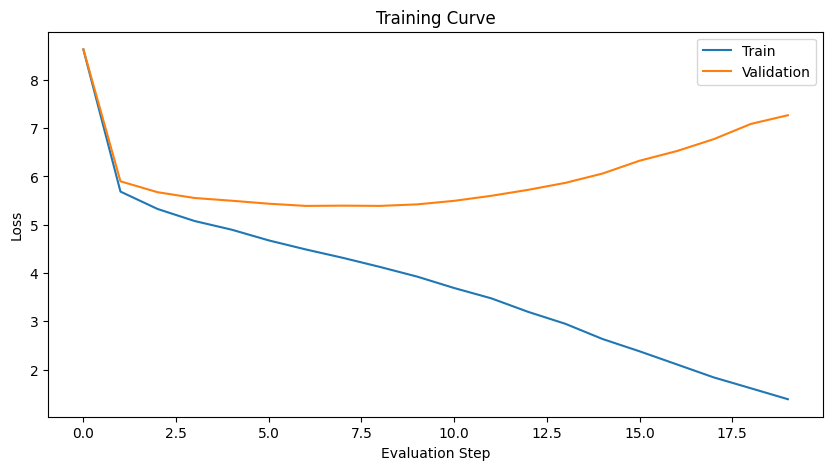

In [12]:
# Plot Loss
plt.figure(
    figsize=(10,5)
)

plt.plot(
    train_losses,
    label="Train"
)

plt.plot(
    val_losses,
    label="Validation"
)

plt.legend()

plt.xlabel(
    "Evaluation Step"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Training Curve"
)

plt.show()

### Generate Text

In [13]:
context = torch.zeros(
    (1,1),
    dtype=torch.long,
    device=device
)

generated = model.generate(

    context,

    max_new_tokens=300

)

generated_ids = (
    generated[0]
    .tolist()
)

generated_ids = (
    generated[0]
    .tolist()
)

In [16]:
from tokenizers import Tokenizer

tokenizer = Tokenizer.from_file(
    "tokenizer.json"
)

In [17]:
context = torch.zeros(
    (1,1),
    dtype=torch.long,
    device=device
)

generated = model.generate(

    context,

    max_new_tokens=300

)

generated_ids = (
    generated[0]
    .tolist()
)

text = tokenizer.decode(
    generated_ids
)

print(text)

ty late ? KING RICHARD III : Not that I but dream ? QUEEN MARGARET : What -- KING RICHARD III : An if age Edward be his grace ! DUCHESS OF YORK : Thy un lawful loss , my son be convey ' d unts ! QUEEN ELIZABETH : Thy old God ' s mis dar ed loss , you knew no soon to inf in a royal disposition . QUEEN ELIZABETH : My Lord of Lancaster gates are comest to Richmond ; ted t ind irect mis fortune and good night ; The lips sudden mean er than war g ers of Buckingham , GREEN : We have lost all ied him live ; ed s hand led , kind , though we wear their traitor re tired to our royal children ; Even to - morrow next room , plot ted steeds , and entreat ies , And leave your conference with truth , Which since which alone with God ' s promise of the battle let this be know ' s come before : They are king , and be not proud , They shall not wed lament able and secre ts i val ued Marcius , but according ly offi cers , I ' ll back again . O Perdita , O Warwick , say I remember ; And I , doubt not , mo

### What i have done here

Dataset -> MiniGPT -> Forward Pass -> Cross Entropy Loss -> Backpropagation -> AdamW -> Update Weights -> Learn Language